## Import libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Load dataset

In [10]:
# Load built-in dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# View first few rows
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


## Scale the data

In [11]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

## Elbow method

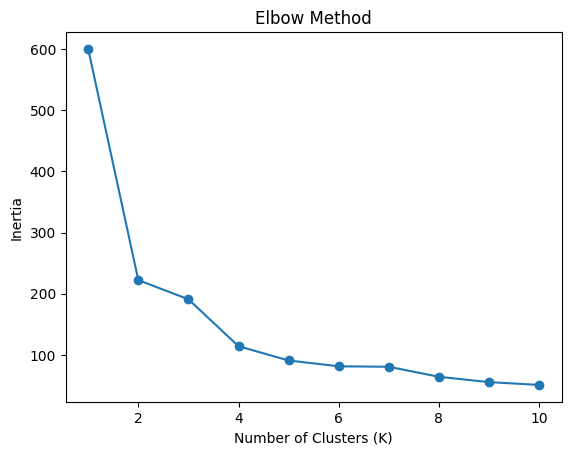

In [12]:
inertia = []

# Test K values from 1–10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Visualize the elbow
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## Implement the k-means model

In [13]:
# Choose K = 3 (from elbow)
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model
kmeans.fit(scaled_data)

# Add cluster labels to dataset
df['Cluster'] = kmeans.labels_

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


## Visualize the clusters

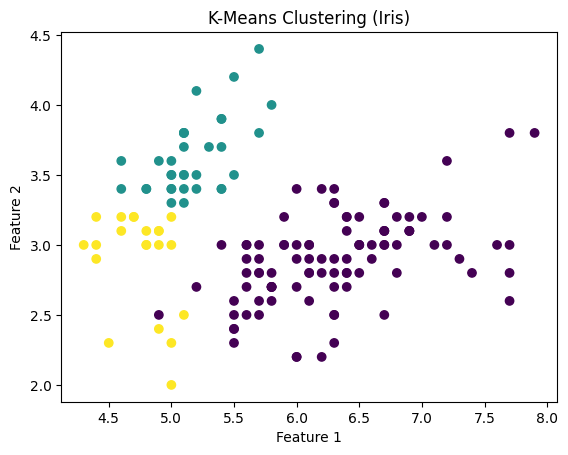

In [14]:
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df['Cluster'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering (Iris)')
plt.show()